   step  train_batch_loss
0   100            3.7994
1   200            3.6264
2   300            3.5051
3   400            3.3918
4   500            3.3521
    epoch  num_epochs  train_loss  train_exact  val_loss  val_exact  \
0       1          15      0.3026       0.7792    0.1730     0.8566   
1       2          15      0.1699       0.8551    0.1449     0.8769   
2       3          15      0.1489       0.8704    0.1348     0.8847   
3       4          15      0.1366       0.8794    0.1287     0.8922   
4       5          15      0.1285       0.8852    0.1197     0.8979   
5       6          15      0.1220       0.8898    0.1167     0.9000   
6       7          15      0.1172       0.8935    0.1135     0.9018   
7       8          15      0.1130       0.8964    0.1121     0.9041   
8       9          15      0.1096       0.8989    0.1103     0.9047   
9      10          15      0.1066       0.9011    0.1090     0.9062   
10     11          15      0.1040       0.9031    0.1054     0.

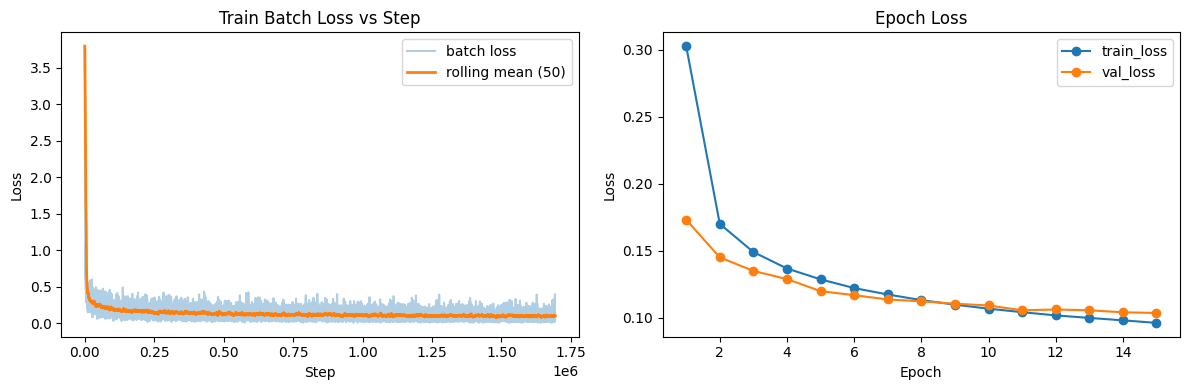

In [9]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

path = Path("/home/isaac/CSC-480-Project/results.txt")
lines = path.read_text(encoding="utf-8").splitlines()

step_re = re.compile(r"^step=(\d+)\s+train_batch_loss=([0-9.]+)$")
epoch_re = re.compile(
    r"^Epoch\s+(\d+)/(\d+)\s+\|\s+train_loss=([0-9.]+)\s+train_exact=([0-9.]+)\s+\|\s+val_loss=([0-9.]+)\s+val_exact=([0-9.]+)\s+\|\s+([0-9.]+)s$"
)
test_re = re.compile(r"^Test\s+\|\s+loss=([0-9.]+)\s+exact=([0-9.]+)$")

step_rows = []
epoch_rows = []
test_metrics = None

for line in lines:
    m = step_re.match(line)
    if m:
        step_rows.append({"step": int(m.group(1)), "train_batch_loss": float(m.group(2))})
        continue

    m = epoch_re.match(line)
    if m:
        epoch_rows.append({
            "epoch": int(m.group(1)),
            "num_epochs": int(m.group(2)),
            "train_loss": float(m.group(3)),
            "train_exact": float(m.group(4)),
            "val_loss": float(m.group(5)),
            "val_exact": float(m.group(6)),
            "epoch_seconds": float(m.group(7)),
        })
        continue

    m = test_re.match(line)
    if m:
        test_metrics = {"test_loss": float(m.group(1)), "test_exact": float(m.group(2))}

df_steps = pd.DataFrame(step_rows)
df_epochs = pd.DataFrame(epoch_rows)

print(df_steps.head())
print(df_epochs)
print("test:", test_metrics)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(df_steps["step"], df_steps["train_batch_loss"], alpha=0.35, label="batch loss")
ax[0].plot(
    df_steps["step"],
    df_steps["train_batch_loss"].rolling(50, min_periods=1).mean(),
    linewidth=2,
    label="rolling mean (50)"
)
ax[0].set_title("Train Batch Loss vs Step")
ax[0].set_xlabel("Step")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(df_epochs["epoch"], df_epochs["train_loss"], marker="o", label="train_loss")
ax[1].plot(df_epochs["epoch"], df_epochs["val_loss"], marker="o", label="val_loss")
ax[1].set_title("Epoch Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()

plt.tight_layout()
plt.show()
